# Feature Engineering & Preprocessing Strategy
**Goal:** Transform the raw insights from EDA into a model-ready dataset. We will apply stateless transformations, handle outliers, transform the skewed target variable, and finalize our blueprint for stateful encoding/scaling.

In [5]:
# 1. Imports & Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Ensure we can import from our src folder
sys.path.append('../')
from src.features.build_features import engineer_stateless_features

# Aesthetics
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Load Interim Data
Loading the cleaned data.

In [6]:
df = pd.read_csv('../data/interim/used_cars_cleaned.csv')
display(df.head())

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,98000.0,Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,Volkswagen,VentoTest,2010,14,77246.0,Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
2,Maruti Suzuki,Swift,2017,7,83500.0,Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
3,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000
4,BMW,X3,2014,10,83000.0,Automatic,first,Diesel,Nov-24,"BMW X3 2.0 XDRIVE 20D, 2014, Diesel",1350000


## 2. Target Transformation (`AskPrice`)
The target variable is severely right-skewed (8.39). We apply a Log1p transformation to bring it closer to a normal distribution, preventing multi-crore outliers from ruining the regression weights.

Original AskPrice Skewness: 8.39
Log-Transformed AskPrice Skewness: 0.42


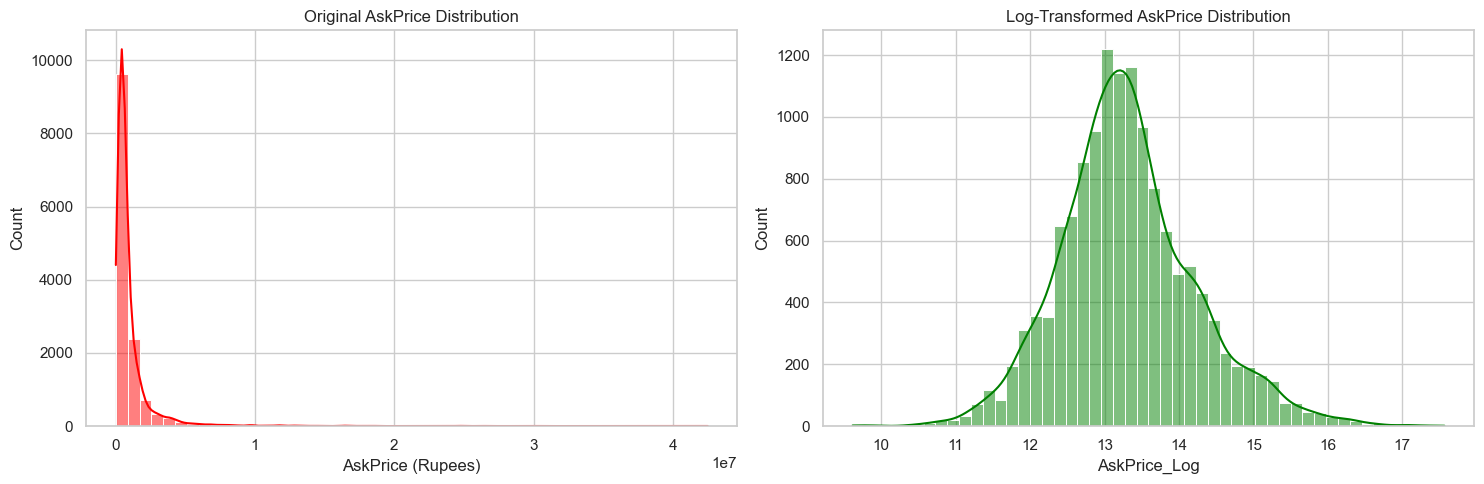

In [7]:
# 1. Load the data (assuming your notebook is in the 'notebooks' folder)
df = pd.read_csv('../data/interim/used_cars_cleaned.csv')

# 2. Apply the Log1p transform
df['AskPrice_Log'] = np.log1p(df['AskPrice'])

# 3. Calculate numerical skewness
original_skew = df['AskPrice'].skew()
log_skew = df['AskPrice_Log'].skew()

print(f"Original AskPrice Skewness: {original_skew:.2f}")
print(f"Log-Transformed AskPrice Skewness: {log_skew:.2f}")

# 4. Visual Verification
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Original
sns.histplot(df['AskPrice'], kde=True, ax=axes[0], color='red', bins=50)
axes[0].set_title('Original AskPrice Distribution')
axes[0].set_xlabel('AskPrice (Rupees)')

# Plot Log Transformed
sns.histplot(df['AskPrice_Log'], kde=True, ax=axes[1], color='green', bins=50)
axes[1].set_title('Log-Transformed AskPrice Distribution')
axes[1].set_xlabel('AskPrice_Log')

plt.tight_layout()
plt.show()

## 3. Stateless Feature Engineering Sandbox
Testing our assumptions before moving them to `src/`.
- **FuelType:** Lowercasing for consistency.
- **Year:** Dropping to prevent perfect multicollinearity with `Age`.
- **kmDriven:** Hard clipping at 300,000 km to handle extreme outliers statelessly.
- **Useless Columns:** Dropping high-cardinality/unusable text columns.

In [3]:
# 1. Clean FuelType casing
df['FuelType'] = df['FuelType'].str.lower()

# 2. Drop the redundant Year column
if 'Year' in df.columns:
    df = df.drop(columns=['Year'])

# 3. Cap kmDriven at 300,000
df['kmDriven'] = df['kmDriven'].clip(upper=300000)

# Verification
print("Unique Fuel Types:", df['FuelType'].unique().tolist())
print("Max kmDriven after clipping:", df['kmDriven'].max())
print("Columns remaining:", df.columns.tolist())

Unique Fuel Types: ['petrol', 'diesel', 'hybrid/cng', 'hybrid']
Max kmDriven after clipping: 300000.0
Columns remaining: ['Brand', 'model', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice', 'AskPrice_Log']


## 4. Final Pipeline Execution & Save
Testing the centralized function from `src/features/build_features.py` to ensure reproducible execution, and saving the output for Phase 6.

In [8]:
# Apply the function imported from src/
df_engineered = engineer_stateless_features(df)

# Save to disk
df_engineered.to_csv('../data/interim/used_cars_engineered.csv', index=False)
print(f"Data saved successfully. Shape: {df_engineered.shape}")

Data saved successfully. Shape: (13652, 8)
